# Complete Neural Network Training for a Toy ELMo Model

### Goal: train on two sentences containing "bank" in two senses and show that the two occurrences receive different embeddings.

<br></br>
<br></br>

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from collections import Counter

torch.manual_seed(42)

# STEP 1: Define the toy corpus

In [2]:
corpus = [
    "I deposited money at the bank",
    "I withdrew money from the bank",
    "The fisherman sat on the bank of the river"
]

tokenized_corpus = [sentence.split() for sentence in corpus]

print("STEP 1: Toy Corpus")
for i, sent in enumerate(tokenized_corpus, start=1):
    print(f"Sentence {i}: {sent}")

STEP 1: Toy Corpus
Sentence 1: ['I', 'deposited', 'money', 'at', 'the', 'bank']
Sentence 2: ['I', 'withdrew', 'money', 'from', 'the', 'bank']
Sentence 3: ['The', 'fisherman', 'sat', 'on', 'the', 'bank', 'of', 'the', 'river']


# STEP 2: Build word vocabulary

In [3]:
all_words = [word for sentence in tokenized_corpus for word in sentence]
word_counts = Counter(all_words)

vocab = sorted(set(all_words))
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

print("STEP 2: Word Vocabulary")
print("Vocabulary:", vocab)
print("Vocabulary size:", len(vocab))

STEP 2: Word Vocabulary
Vocabulary: ['I', 'The', 'at', 'bank', 'deposited', 'fisherman', 'from', 'money', 'of', 'on', 'river', 'sat', 'the', 'withdrew']
Vocabulary size: 14


# STEP 3: Build character vocabulary

In [4]:
all_chars = sorted(set("".join(all_words)))
char_to_idx = {ch: i + 1 for i, ch in enumerate(all_chars)}   # reserve 0 for padding
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print("STEP 3: Character Vocabulary")
print("Characters:", all_chars)
print("Character vocabulary size (including padding):", len(char_to_idx) + 1)

STEP 3: Character Vocabulary
Characters: ['I', 'T', 'a', 'b', 'd', 'e', 'f', 'h', 'i', 'k', 'm', 'n', 'o', 'p', 'r', 's', 't', 'v', 'w', 'y']
Character vocabulary size (including padding): 21


# STEP 4: Find maximum word length

In [5]:
max_word_len = max(len(word) for word in all_words)
longest_word = max(all_words, key=len)

print("STEP 4: Maximum Word Length")
print("Max word length:", max_word_len)
print("Longest word   :", longest_word)

STEP 4: Maximum Word Length
Max word length: 9
Longest word   : deposited


# STEP 5: Utility functions

In [6]:
def word_to_char_ids(word, char_to_idx, max_len):
    ids = [char_to_idx[ch] for ch in word]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

def sentence_to_char_tensor(tokens, char_to_idx, max_len):
    return torch.tensor(
        [word_to_char_ids(token, char_to_idx, max_len) for token in tokens],
        dtype=torch.long
    )

def sentence_to_word_tensor(tokens, word_to_idx):
    return torch.tensor(
        [word_to_idx[token] for token in tokens],
        dtype=torch.long
    )

# STEP 6: Prepare training tensors

In [7]:
char_tensors = [sentence_to_char_tensor(tokens, char_to_idx, max_word_len)
                for tokens in tokenized_corpus]

word_tensors = [sentence_to_word_tensor(tokens, word_to_idx)
                for tokens in tokenized_corpus]

print("STEP 6: Training Tensors Prepared")
for i, (char_tensor, word_tensor) in enumerate(zip(char_tensors, word_tensors), start=1):
    print(f"Sentence {i} char tensor shape :", tuple(char_tensor.shape))
    print(f"Sentence {i} word tensor shape :", tuple(word_tensor.shape))

STEP 6: Training Tensors Prepared
Sentence 1 char tensor shape : (6, 9)
Sentence 1 word tensor shape : (6,)
Sentence 2 char tensor shape : (6, 9)
Sentence 2 word tensor shape : (6,)
Sentence 3 char tensor shape : (9, 9)
Sentence 3 word tensor shape : (9,)


# STEP 7: Define a trainable toy ELMo model

In [8]:
class ToyELMo(nn.Module):
    def __init__(
        self,
        char_vocab_size,
        word_vocab_size,
        char_embed_dim=8,
        cnn_filters=16,
        cnn_kernel_size=3,
        lstm_hidden_size=12
    ):
        super().__init__()

        # Character embedding
        self.char_embedding = nn.Embedding(
            num_embeddings=char_vocab_size,
            embedding_dim=char_embed_dim,
            padding_idx=0
        )

        # Character CNN
        self.char_cnn = nn.Conv1d(
            in_channels=char_embed_dim,
            out_channels=cnn_filters,
            kernel_size=cnn_kernel_size,
            padding=1
        )

        # Two stacked bidirectional LSTMs
        self.bi_lstm_1 = nn.LSTM(
            input_size=cnn_filters,
            hidden_size=lstm_hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.bi_lstm_2 = nn.LSTM(
            input_size=2 * lstm_hidden_size,
            hidden_size=lstm_hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # Layer weights for ELMo combination
        self.layer_weights = nn.Parameter(torch.tensor([0.0, 0.0, 0.0]))

        # Output projection to vocabulary for language modeling
        self.output_layer = nn.Linear(2 * lstm_hidden_size, word_vocab_size)

    def forward(self, char_ids):
        # char_ids shape = (seq_len, max_word_len)

        # STEP A: character embeddings
        char_embeds = self.char_embedding(char_ids)                    # (seq_len, max_word_len, char_embed_dim)

        # STEP B: CNN over characters
        cnn_input = char_embeds.transpose(1, 2)                       # (seq_len, char_embed_dim, max_word_len)
        cnn_output = self.char_cnn(cnn_input)                         # (seq_len, cnn_filters, max_word_len)

        # STEP C: max pooling to get token representations
        token_representations = torch.max(cnn_output, dim=2).values   # (seq_len, cnn_filters)

        # STEP D: add batch dimension
        sequence_input = token_representations.unsqueeze(0)           # (1, seq_len, cnn_filters)

        # STEP E: first bi-LSTM
        lstm1_output, _ = self.bi_lstm_1(sequence_input)              # (1, seq_len, 2*hidden)

        # STEP F: second bi-LSTM
        lstm2_output, _ = self.bi_lstm_2(lstm1_output)                # (1, seq_len, 2*hidden)

        # STEP G: normalize layer weights
        normalized_weights = torch.softmax(self.layer_weights, dim=0)

        # STEP H: project token representations to match LSTM dimension
        token_projection = torch.zeros_like(lstm1_output)
        token_projection[:, :, :token_representations.shape[1]] = sequence_input

        # STEP I: weighted sum = final ELMo representation
        final_elmo = (
            normalized_weights[0] * token_projection +
            normalized_weights[1] * lstm1_output +
            normalized_weights[2] * lstm2_output
        )                                                             # (1, seq_len, 2*hidden)

        # STEP J: predict vocabulary distribution at each token
        logits = self.output_layer(final_elmo)                        # (1, seq_len, vocab_size)

        return {
            "char_embeds": char_embeds,
            "cnn_output": cnn_output,
            "token_representations": token_representations,
            "lstm1_output": lstm1_output,
            "lstm2_output": lstm2_output,
            "layer_weights": normalized_weights,
            "final_elmo": final_elmo,
            "logits": logits
        }

# STEP 8: Create model

In [9]:
model = ToyELMo(
    char_vocab_size=len(char_to_idx) + 1,
    word_vocab_size=len(vocab),
    char_embed_dim=8,
    cnn_filters=16,
    cnn_kernel_size=3,
    lstm_hidden_size=12
)

print("STEP 8: Model Created")
print(model)

STEP 8: Model Created
ToyELMo(
  (char_embedding): Embedding(21, 8, padding_idx=0)
  (char_cnn): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (bi_lstm_1): LSTM(16, 12, batch_first=True, bidirectional=True)
  (bi_lstm_2): LSTM(24, 12, batch_first=True, bidirectional=True)
  (output_layer): Linear(in_features=24, out_features=14, bias=True)
)


# STEP 9: Define training objective

We use a simple token-level reconstruction objective: predict each token from its contextual representation.


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("STEP 9: Training Setup")
print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")

STEP 9: Training Setup
Loss function : CrossEntropyLoss
Optimizer     : Adam


# STEP 10: Training loop

In [11]:
epochs = 500
loss_history = []

print("STEP 10: Training Begins")

for epoch in range(1, epochs + 1):
    total_loss = 0.0

    for char_input, target_words in zip(char_tensors, word_tensors):
        optimizer.zero_grad()

        outputs = model(char_input)
        logits = outputs["logits"].squeeze(0)     # (seq_len, vocab_size)

        loss = criterion(logits, target_words)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(char_tensors)
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
        print(f"Epoch {epoch:>3} | Average Loss = {avg_loss:.6f}")

STEP 10: Training Begins
Epoch   1 | Average Loss = 2.609834
Epoch  50 | Average Loss = 0.004090
Epoch 100 | Average Loss = 0.001007
Epoch 150 | Average Loss = 0.000458
Epoch 200 | Average Loss = 0.000262
Epoch 250 | Average Loss = 0.000169
Epoch 300 | Average Loss = 0.000118
Epoch 350 | Average Loss = 0.000087
Epoch 400 | Average Loss = 0.000066
Epoch 450 | Average Loss = 0.000052
Epoch 500 | Average Loss = 0.000042


# STEP 11: Plot loss curve

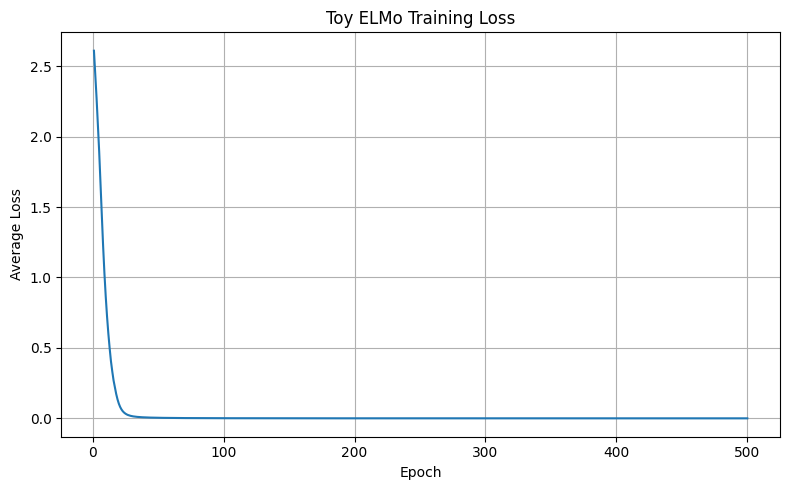

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Toy ELMo Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 12: Inspect learned layer weights

In [13]:
print("STEP 12: Learned Layer Weights")
with torch.no_grad():
    learned_weights = torch.softmax(model.layer_weights, dim=0).numpy()

print("Softmax-normalised layer weights:", learned_weights)

STEP 12: Learned Layer Weights
Softmax-normalised layer weights: [0.72368336 0.12704778 0.14926891]


# STEP 13: Extract final ELMo embeddings for the sentences

In [14]:
print("STEP 13: Final Contextual Embeddings for Each Sentence (Compact View)")

all_sentence_outputs = []
with torch.no_grad():
    for i, char_input in enumerate(char_tensors, start=1):
        outputs = model(char_input)
        final_elmo = outputs["final_elmo"].squeeze(0)   # (seq_len, 24)
        all_sentence_outputs.append(final_elmo)

        tokens = tokenized_corpus[i - 1]

        print(f"\nSentence {i}: {' '.join(tokens)}")
        print("Embedding shape:", tuple(final_elmo.shape))

        # Convert to DataFrame
        elmo_df = pd.DataFrame(
            final_elmo.detach().numpy(),
            index=tokens
        )

        # Round values for readability
        elmo_df = elmo_df.round(3)

        # Transpose so words are columns
        elmo_df = elmo_df.T

        print("\nWord Embeddings (Rounded):")
        print(elmo_df.to_string())
        print("-" * 100)

STEP 13: Final Contextual Embeddings for Each Sentence (Compact View)

Sentence 1: I deposited money at the bank
Embedding shape: (6, 24)

Word Embeddings (Rounded):
        I  deposited  money     at    the   bank
0  -0.776      4.353  5.340  1.505  3.569 -0.498
1   0.431      6.770  0.208  4.302  0.059  3.686
2   2.626      7.103  1.224  3.981  7.562 -0.469
3   1.807      4.085 -0.043  7.992  3.887  1.658
4  -0.675      1.520  9.131 -0.054 -0.849  2.391
5  -0.098      1.159  4.692  3.878  0.840  2.464
6   3.102      0.385  2.337 -0.174 -0.183  0.219
7   3.481      2.556  4.028  0.126  2.203  0.069
8   2.046      1.706  1.585  0.607  3.216  5.941
9  -0.264      7.267  3.564  2.827  4.040  4.516
10 -0.364      0.897  9.762 -0.410 -0.366  6.491
11 -0.589     -1.206  2.391  3.720  6.254  5.289
12  2.393      2.059  8.711 -0.414 -0.318  4.866
13 -0.573     -0.285  2.457  0.324  5.645  5.403
14  1.468      9.772  0.521 -0.466 -0.061  4.480
15 -0.363      5.000  0.900  3.334  7.827  1.088
1

# STEP 14: Locate the word "bank" in the sentences

In [15]:
bank_positions = []

for sent_idx, tokens in enumerate(tokenized_corpus):
    for token_idx, token in enumerate(tokens):
        if token == "bank":
            bank_positions.append((sent_idx, token_idx))

print("STEP 14: Positions of 'bank'")
for sent_idx, token_idx in bank_positions:
    print(f"'bank' in sentence {sent_idx + 1} at token position {token_idx}")

STEP 14: Positions of 'bank'
'bank' in sentence 1 at token position 5
'bank' in sentence 2 at token position 5
'bank' in sentence 3 at token position 5


# STEP 15: Extract the contextual embeddings for "bank"

In [16]:
print("STEP 15: Contextual Embeddings of 'bank' (All Sentences)")

with torch.no_grad():
    for i, (sent_idx, token_idx) in enumerate(bank_positions):
        bank_embedding = all_sentence_outputs[sent_idx][token_idx]

        print(f"Sentence {sent_idx + 1}:", " ".join(tokenized_corpus[sent_idx]))
        print(bank_embedding.numpy())
        print()

STEP 15: Contextual Embeddings of 'bank' (All Sentences)
Sentence 1: I deposited money at the bank
[-4.9813271e-01  3.6863830e+00 -4.6887952e-01  1.6576426e+00
  2.3907111e+00  2.4641480e+00  2.1877111e-01  6.9456682e-02
  5.9411764e+00  4.5155487e+00  6.4905086e+00  5.2889414e+00
  4.8663912e+00  5.4032760e+00  4.4799619e+00  1.0881929e+00
 -2.5675558e-02  5.7912257e-02 -8.7316208e-02  1.8474534e-01
 -9.0319261e-02  6.4717419e-03 -1.9617519e-01 -5.4189116e-03]

Sentence 2: I withdrew money from the bank
[-4.5786664e-01  3.7542028e+00 -4.7009319e-01  1.6533086e+00
  2.3979220e+00  2.4581370e+00  2.5315058e-01  2.2710651e-01
  5.9554334e+00  4.4955831e+00  6.5792179e+00  5.2583075e+00
  4.8756561e+00  5.3808985e+00  4.4158731e+00  1.1012403e+00
  2.4268676e-03  5.8599714e-02 -8.5246503e-02  1.7941004e-01
 -9.8181002e-02 -8.2285814e-03 -1.9011617e-01 -1.8307790e-03]

Sentence 3: The fisherman sat on the bank of the river
[-0.53971875  3.5469     -0.4703201   1.6646682   2.4405684   2.220

# STEP 16: Compare the bank embeddings numerically

In [17]:
print("STEP 16: Pairwise Comparison of 'bank' Embeddings")

with torch.no_grad():
    bank_embeddings = [
        all_sentence_outputs[sent_idx][token_idx]
        for sent_idx, token_idx in bank_positions
    ]

    num_embeddings = len(bank_embeddings)

    for i in range(num_embeddings):
        for j in range(i + 1, num_embeddings):
            emb_i = bank_embeddings[i]
            emb_j = bank_embeddings[j]

            difference = emb_i - emb_j
            l2_distance = torch.norm(difference, p=2).item()
            cosine_similarity = torch.nn.functional.cosine_similarity(
                emb_i.unsqueeze(0),
                emb_j.unsqueeze(0)
            ).item()

            print(f"\nComparison: Sentence {bank_positions[i][0] + 1} vs Sentence {bank_positions[j][0] + 1}")
            print("L2 distance       :", l2_distance)
            print("Cosine similarity :", cosine_similarity)

STEP 16: Pairwise Comparison of 'bank' Embeddings

Comparison: Sentence 1 vs Sentence 2
L2 distance       : 0.21860702335834503
Cosine similarity : 0.9998967051506042

Comparison: Sentence 1 vs Sentence 3
L2 distance       : 0.8353821039199829
Cosine similarity : 0.9987598061561584

Comparison: Sentence 2 vs Sentence 3
L2 distance       : 0.8666849136352539
Cosine similarity : 0.9986798763275146


# STEP 17: Show the embeddings side by side in a DataFrame

In [18]:
print("STEP 17: Side-by-Side Comparison of 'bank' Embeddings")

with torch.no_grad():
    bank_embeddings = [
        all_sentence_outputs[sent_idx][token_idx]
        for sent_idx, token_idx in bank_positions
    ]

    num_embeddings = len(bank_embeddings)

    for i in range(num_embeddings):
        for j in range(i + 1, num_embeddings):
            emb_i = bank_embeddings[i]
            emb_j = bank_embeddings[j]

            difference = emb_i - emb_j

            comparison_df = pd.DataFrame({
                f"Sentence_{bank_positions[i][0] + 1}": emb_i.numpy(),
                f"Sentence_{bank_positions[j][0] + 1}": emb_j.numpy(),
                "difference": difference.numpy()
            })

            print(f"\nComparison: Sentence {bank_positions[i][0] + 1} vs Sentence {bank_positions[j][0] + 1}")
            print(comparison_df)

STEP 17: Side-by-Side Comparison of 'bank' Embeddings

Comparison: Sentence 1 vs Sentence 2
    Sentence_1  Sentence_2  difference
0    -0.498133   -0.457867   -0.040266
1     3.686383    3.754203   -0.067820
2    -0.468880   -0.470093    0.001214
3     1.657643    1.653309    0.004334
4     2.390711    2.397922   -0.007211
5     2.464148    2.458137    0.006011
6     0.218771    0.253151   -0.034379
7     0.069457    0.227107   -0.157650
8     5.941176    5.955433   -0.014257
9     4.515549    4.495583    0.019966
10    6.490509    6.579218   -0.088709
11    5.288941    5.258307    0.030634
12    4.866391    4.875656   -0.009265
13    5.403276    5.380898    0.022377
14    4.479962    4.415873    0.064089
15    1.088193    1.101240   -0.013047
16   -0.025676    0.002427   -0.028102
17    0.057912    0.058600   -0.000687
18   -0.087316   -0.085247   -0.002070
19    0.184745    0.179410    0.005335
20   -0.090319   -0.098181    0.007862
21    0.006472   -0.008229    0.014700
22   -0.196

# STEP 18: Display nearest interpretation

In [19]:
print("STEP 18: Interpretation")
print("If the two embeddings were identical, their difference would be zero")
print("and cosine similarity would be exactly 1.")
print("A non-zero difference shows that ELMo has assigned different")
print("context-sensitive embeddings to the same word 'bank' in the two sentences.")

STEP 18: Interpretation
If the two embeddings were identical, their difference would be zero
and cosine similarity would be exactly 1.
A non-zero difference shows that ELMo has assigned different
context-sensitive embeddings to the same word 'bank' in the two sentences.
